# Load in the libs
### The function calls are all the same it is just the library that changes hence you only change the import library line

In [1]:
# Python Libs
import numpy as np
import matplotlib.pyplot as plt
import time
plt.style.use('dark_background')

import pwi_inst.hardware.SLM.MeadowlarkBlinkPlus.MeadowlarkBlinkPlusObject as slmlib
# import pwi_inst.hardware.SLM.MeadowlarkBlinkOverDrivePlus.MeadowlarkBlinkOneDrivePlusObject as slmlib
import pwi_inst.utils.GenerateSimplePhaseMasks as slm_masks
import pwi_inst.hardware.SLM.PhaseMaskClass as PhaseMaskClass
import pwi_inst.hardware.SLM.SLM_Server as SLM_Serverlib
import pwi_inst.hardware.SLM.SLM_Client as SLM_Clientlib
import pwi_inst.hardware.SLM.SLM_Viewer as SLM_Viewerlib

# import pwi_inst.utils.GenerateSimplePhaseMasks as slm_masks
# import pwi_inst.hardware.SLM.PhaseMaskClass as PhaseMaskClass

In [2]:
%load_ext autoreload
%aimport pwi_inst.hardware.SLM.MeadowlarkBlinkPlus.MeadowlarkBlinkPlusObject

# %aimport pwi_inst.hardware.SLM.MeadowlarkBlinkOneDrivePlus.MeadowlarkBlinkOneDrivePlusObject
%aimport pwi_inst.hardware.SLM.SLM_Server 
%aimport pwi_inst.hardware.SLM.SLM_Client
%aimport pwi_inst.hardware.SLM.SLM_Viewer

%aimport pwi_inst.hardware.SLM.PhaseMaskClass

%autoreload 1


# Jitter test

=== Write Time ===
Mean:   0.751 ms
Std:    0.236 ms
Min:    0.477 ms
Max:    3.325 ms
Jitter: 2.849 ms

=== Loop Interval (important for AO) ===
Mean:   2.572 ms
Std:    0.317 ms
Min:    2.185 ms
Max:    5.627 ms
Jitter: 3.442 ms


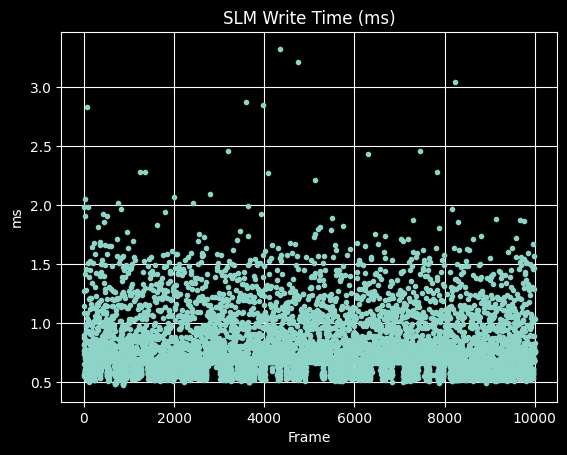

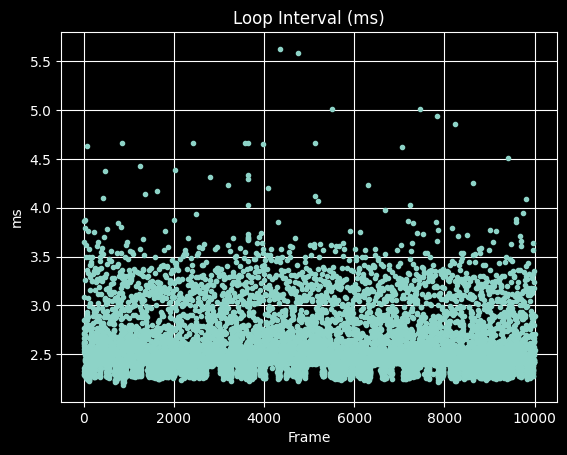

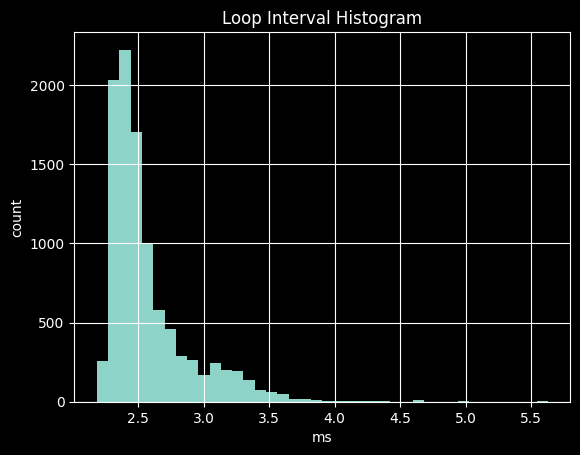

In [75]:
import time
import numpy as np
import matplotlib.pyplot as plt

n_frames = 10000

write_times = []
loop_intervals = []

last_t = None

for i in range(n_frames):
    img = np.random.randint(
        0,
        255,
        (slmobj_client.monitor_height, slmobj_client.monitor_width),
        dtype=np.uint8,
    )

    t0 = time.perf_counter()

    if last_t is not None:
        loop_intervals.append(t0 - last_t)

    # ---- your actual call ----
    slmobj_client.WriteImageToSLM(img, channelIdx=0)
    # -------------------------

    t1 = time.perf_counter()

    write_times.append(t1 - t0)
    last_t = t0


write_times = np.array(write_times)
loop_intervals = np.array(loop_intervals)

# --------------------------------------------------
# Print stats
# --------------------------------------------------
print("=== Write Time ===")
print(f"Mean:   {np.mean(write_times)*1e3:.3f} ms")
print(f"Std:    {np.std(write_times)*1e3:.3f} ms")
print(f"Min:    {np.min(write_times)*1e3:.3f} ms")
print(f"Max:    {np.max(write_times)*1e3:.3f} ms")
print(f"Jitter: {(np.max(write_times)-np.min(write_times))*1e3:.3f} ms")

print("\n=== Loop Interval (important for AO) ===")
print(f"Mean:   {np.mean(loop_intervals)*1e3:.3f} ms")
print(f"Std:    {np.std(loop_intervals)*1e3:.3f} ms")
print(f"Min:    {np.min(loop_intervals)*1e3:.3f} ms")
print(f"Max:    {np.max(loop_intervals)*1e3:.3f} ms")
print(f"Jitter: {(np.max(loop_intervals)-np.min(loop_intervals))*1e3:.3f} ms")

# --------------------------------------------------
# Plots
# --------------------------------------------------
plt.figure()
plt.plot(write_times * 1e3,'.')
plt.title("SLM Write Time (ms)")
plt.xlabel("Frame")
plt.ylabel("ms")
plt.grid()
plt.show()

plt.figure()
plt.plot(loop_intervals * 1e3,'.')
plt.title("Loop Interval (ms)")
plt.xlabel("Frame")
plt.ylabel("ms")
plt.grid()
plt.show()

plt.figure()
plt.hist(loop_intervals * 1e3, bins=40)
plt.title("Loop Interval Histogram")
plt.xlabel("ms")
plt.ylabel("count")
plt.grid()
plt.show()

In [ ]:
slmobj_client=slmlib.SLMObject(board_number_in=1, RefreshRate=10e-3,LutFile=None)
phasemaskobj=PhaseMaskClass.PhaseMaskObject(SLMObject=slmobj_client, ActiveRGBChannels=["Red"], pixel_size = 17e-6, wavelength=1550e-9)



Create_SDK failed: b'No PCIe hardware found, running in simulation mode'


RuntimeError: No SLM controllers found

# Make some full screen displays and load them on to the SLM while changeing the refresh rate

In [9]:

slmobj_client.GetSLMTemperature()
for i in range(10000):
    # make simple sprial mask that is the size of the display
    MaskCMPLX=slm_masks.SpiralMask(SpiralNum=i,Nx=slmobj_client.monitor_width,Ny=slmobj_client.monitor_height,pixelSize=17e-6, PlotMasks=False)
    MaskInt=phasemaskobj.convert_phase_to_uint8( arr=(MaskCMPLX[0,0,:,:]))
    # MaskInt=np.angle(MaskCMPLX[0,0,:,:]).astype(np.uint8)
    # plt.imshow(MaskInt)
    # change the refresh rate and write the mask to the SLM
    slmobj_client.SetRefreshRate(10e-3)
    #Write the mask to the SLM
    check=bool(slmobj_client.WriteImageToSLM(MaskInt))
    # print(check)


In [ ]:
slmobj_client.SetTriggerOutput(1)

1

: 

In [13]:
del slmobj_client

# Load a lut file

In [17]:

# slm.LoadLutFile(b"C:\\Program Files\\Meadowlark Optics\\Blink OverDrive Plus\\LUT Files\\1024x1024_linearVoltage.lut")
slmobj_client.LoadLutFile("C:\\Program Files\\Meadowlark Optics\\Blink Plus\\LUT Files\\slm7635_at532_30C.lut")


1

# Example of using the phase mask object that opens up more user friendly abilities

In [41]:

phasemaskobj=PhaseMaskClass.PhaseMaskObject(SLMObject=slm, ActiveRGBChannels=["Red"], pixel_size = 17e-6, wavelength=1550e-9)


        Zern Coefs:
        0:  piston    ( 0,  0 )
        1:  Tiltx     (1,  -1 )
        2:  Tilty     ( 1,  1 )
        3:  Astigx    (2,  -2 )
        4:  Defocus   ( 2,  0 )
        5:  Astigy    ( 2,  2 )
        6:  Trefilx   (3,  -3 )
        7:  Comax     (3,  -1 )
        8:  Comay     ( 1,  3 )
        9:  Trefoily  ( 3,  3 )
        12:  Spherical ( 4,  0 )
        
1024
1024
[  1   1 256 256]


# Load Pi flip masks

In [20]:
phasemaskobj.LoadPiFlipMasks(planeCount=1)

[  2   1 256 256]
[  2   1 256 256]


# Example of how to move Masks Around

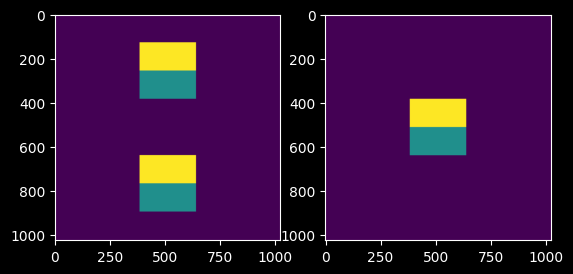

In [21]:


plt.subplot(1,2,1)
plt.imshow(phasemaskobj.FullScreenBuffer_int)
# trun the Vpol mask off
phasemaskobj.polProps["Red"]['V'].polEnabled=False
# move Hpol mask to center
phasemaskobj.AllMaskProperties["Red"]["H"][0].center[1] = 1024//2
phasemaskobj.AllMaskProperties["Red"]["H"][0].center[0] = 1024//2
phasemaskobj.setmask(channel="Red",imode=0)

plt.subplot(1,2,2)
plt.imshow(phasemaskobj.FullScreenBuffer_int)

# SLM Server Example

In [3]:
slmObj = SLM_Serverlib.SLMZMQServer()

In [4]:
slmObj.startProcess()


SLM server process started with PID 21028


In [ ]:

props = slmObj.GetProperties()

In [ ]:





from SLM_Output_Viewer import SLMOutputViewer

props = slmObj.GetProperties()

viewer = SLMOutputViewer(
    shm_name=props["viewer_shared_memory_name"],
    shape=props["viewer_shape"],
    dtype=props["viewer_dtype"],
    window_width=900,
    window_height=500,
    zoom=1.0,
)

viewer.startProcess()

viewer.startProcess()